<a href="https://colab.research.google.com/github/sonakshi-chand/machine-learning_sonakshi/blob/main/LAB_02_Dataprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


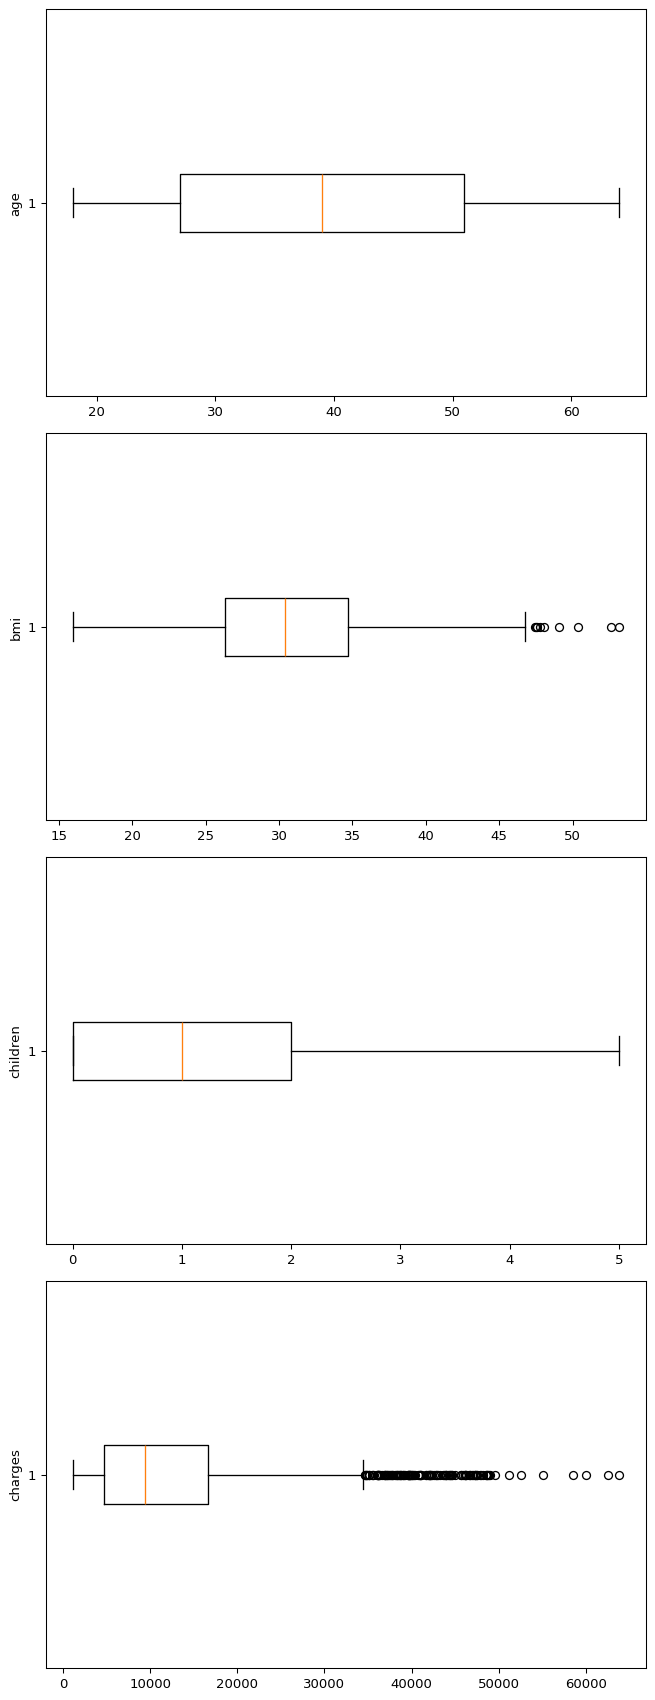

In [ ]:
df.describe()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axs = plt.subplots(len(numerical_cols), 1, figsize=(7, 18), dpi=95)

# Ensure axs is iterable even if there's only one numerical column
if len(numerical_cols) == 1:
    axs = [axs]

for i, col in enumerate(numerical_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
q1, q3 = np.percentile(df['bmi'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]

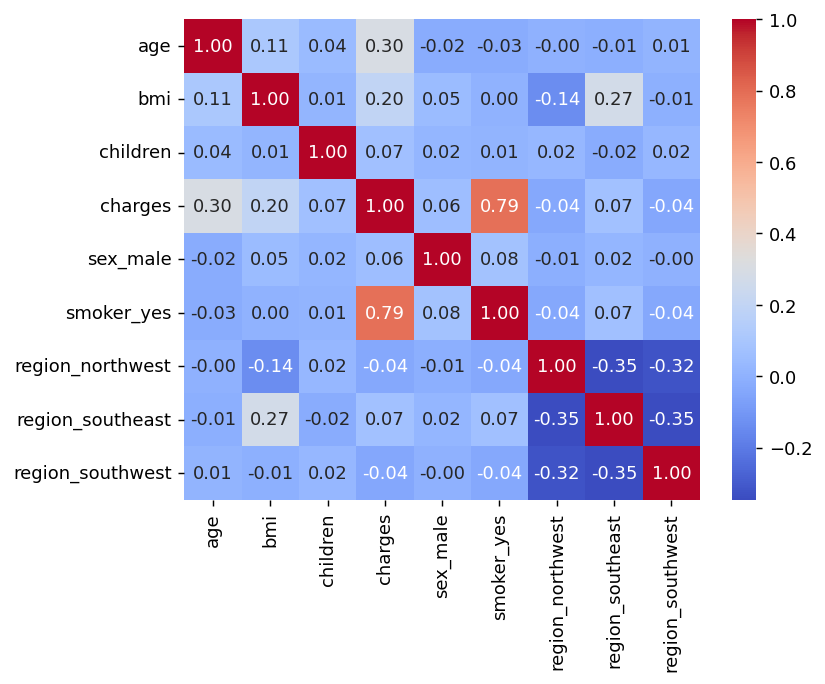

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
corr = df_encoded.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# Assuming 'charges' is the target variable for correlation analysis
print(corr['charges'].sort_values(ascending=False))

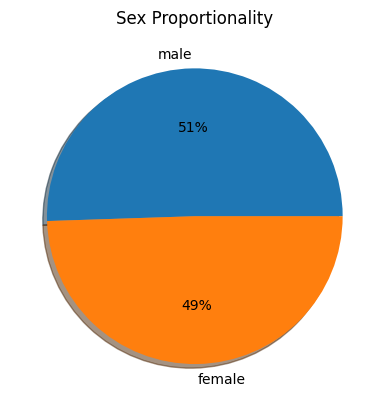

In [ ]:
plt.pie(df['sex'].value_counts(), labels=df['sex'].value_counts().index, autopct='%.f%%', shadow=True)
plt.title('Sex Proportionality')
plt.show()

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

In [ ]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_encoded)
print(X_normalized[:5])

[[0.02173913 0.3212268  0.         0.         1.         0.
  0.         1.        ]
 [0.         0.47914985 0.2        1.         0.         0.
  1.         0.        ]
 [0.2173913  0.45843422 0.6        1.         0.         0.
  1.         0.        ]
 [0.32608696 0.18146355 0.         1.         0.         1.
  0.         0.        ]
 [0.30434783 0.34759214 0.         1.         0.         1.
  0.         0.        ]]


In [ ]:
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_encoded)
print(X_standardized[:5])

[[-1.43876426 -0.45332    -0.90861367 -1.0105187   1.97058663 -0.56641788
  -0.61132367  1.76548098]
 [-1.50996545  0.5096211  -0.07876719  0.98959079 -0.5074631  -0.56641788
   1.63579466 -0.56641788]
 [-0.79795355  0.38330685  1.58092576  0.98959079 -0.5074631  -0.56641788
   1.63579466 -0.56641788]
 [-0.4419476  -1.30553108 -0.90861367  0.98959079 -0.5074631   1.76548098
  -0.61132367 -0.56641788]
 [-0.51314879 -0.29255641 -0.90861367  0.98959079 -0.5074631   1.76548098
  -0.61132367 -0.56641788]]
